Homework 1 - Hydrodynamics

falling plate in water, direction of movement is parallel to the plate. 
different falling angles (alpha) are explored.
the problem is 2 dimensional.
the velocity vector field of the fluid is plotted.

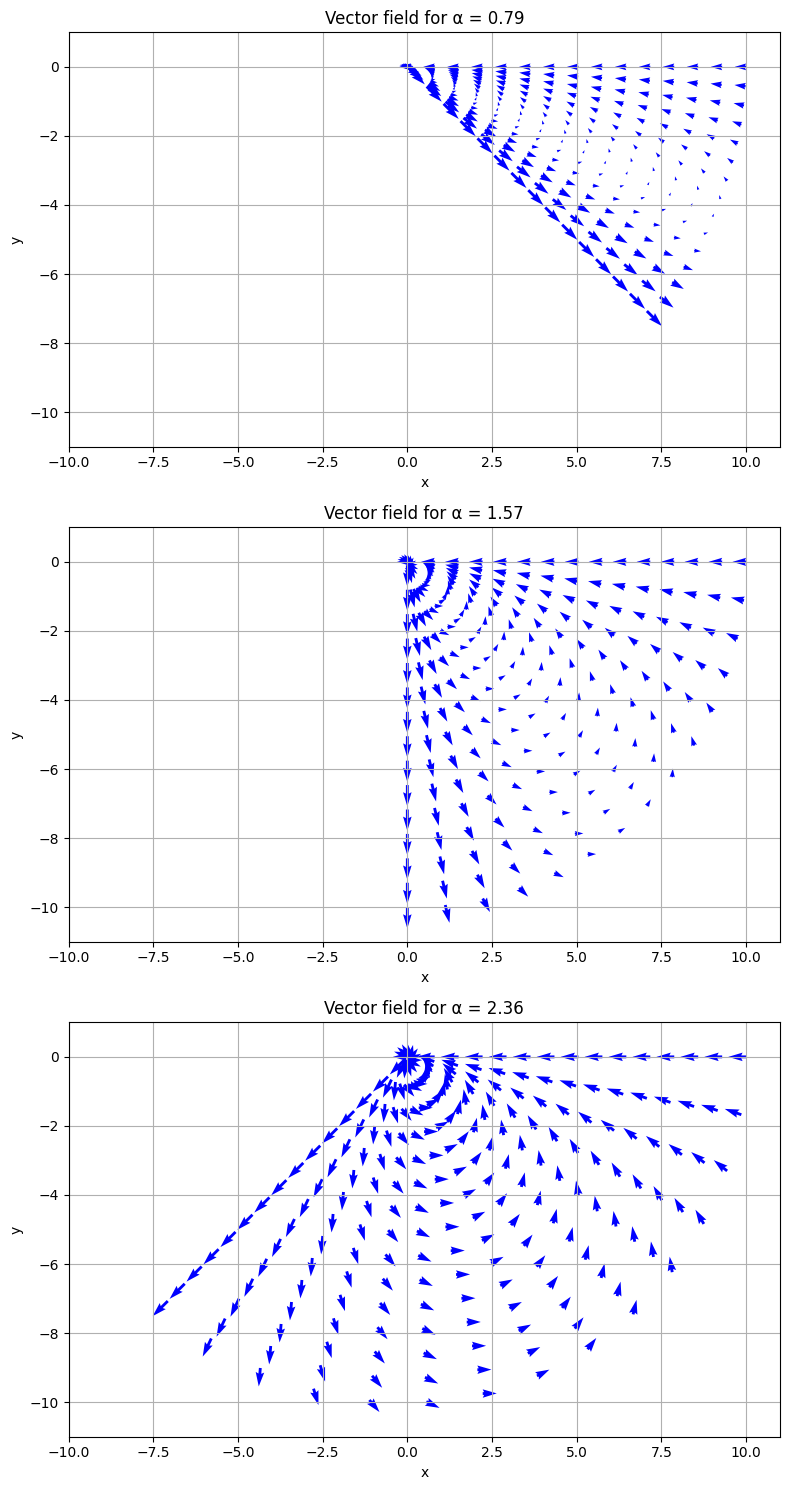

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Definiamo i parametri
U = 0.3  # Fattore di scala
R = 10  # Raggio massimo
alpha_values = [np.pi/4, np.pi/2, 3*np.pi/4]  # Quattro valori di alpha

# Creiamo la griglia in coordinate polari
r_vals = np.linspace(0.1, R, 15)  # Evitiamo r=0 per problemi numerici
theta_vals = np.linspace(-max(alpha_values), 0, 20)  # Theta varia fino a -max(alpha)

# Creiamo una meshgrid
R_grid, Theta_grid = np.meshgrid(r_vals, theta_vals)

# Creiamo il plot per i diversi valori di alpha
fig, axes = plt.subplots(3, 1, figsize=(8, 5*3))

for i, alpha in enumerate(alpha_values):
    # Creiamo la griglia in coordinate polari
    theta_vals = np.linspace(-alpha, 0, 15)  # Theta varia fino a -max(alpha)
    
    # Creiamo una meshgrid
    R_grid, Theta_grid = np.meshgrid(r_vals, theta_vals)
    
    # Normalization factor
    norm_factor = alpha - np.cos(alpha) * np.sin(alpha)

    # Componenti del campo vettoriale in coordinate polari
    u_r = (U / norm_factor) * (alpha * np.cos(alpha) * np.cos(Theta_grid) - np.cos(Theta_grid) * np.sin(alpha) + Theta_grid * np.sin(Theta_grid) * np.sin(alpha))
    u_theta = (U / norm_factor) * (alpha * np.cos(alpha) * np.sin(Theta_grid) - Theta_grid * np.cos(Theta_grid) * np.sin(alpha))

    # Convertiamo in coordinate cartesiane
    X = R_grid * np.cos(Theta_grid)
    Y = R_grid * np.sin(Theta_grid)

    # Componenti cartesiane del campo vettoriale
    U_x = u_r * np.cos(Theta_grid) - u_theta * np.sin(Theta_grid)
    U_y = u_r * np.sin(Theta_grid) + u_theta * np.cos(Theta_grid)

    # Selezioniamo il subplot
    ax = axes[i]
    ax.quiver(X, Y, U_x, U_y, scale=10, color='b')
    ax.set_xlim(-R, R+R/10)
    ax.set_ylim(-R - R/10, R/10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Vector field for α = {alpha:.2f}")
    ax.grid()

plt.tight_layout()
plt.show()
